In [1]:
import random
import re

import pandas as pd
import pytorch_lightning as pl

from sklearn.metrics import roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt

from freestyl.dataset.dataframe_wrapper import DataframeWrapper
from freestyl.supervised.siamese import train_dataframewrappers, get_df_prediction
from freestyl.supervised.siamese.utils import score_from_preds, find_index_of_first_change
from freestyl.utils import plot_aucroc_curve
#>>> x = [1, 2, 3, 4, 5, 6]
#>>> .shuffle(x)

NEW_DATASET = True
SPLIT_ON_AUTHORS = False
USE_POS = True
USE_TRIG = True
USE_FW = True
LR = 1e-4
BATCH = 64
DROPOUT = .3
LOSS = "stn_contrastive"
CHRYSOSTOM = True
SAMPLE = 2
DYDIMUS = True
COMMENT = False
DEV_MINER = True
SPLIT = False
ISDIST = "linear" not in LOSS
METRICKEY = "Probability" if not ISDIST else "Distance"

if SPLIT:
    SIZE = (32, 32, 32)
elif USE_POS and not USE_FW:
    SIZE = 50
elif USE_POS and USE_FW:
    SIZE = 64
else:
    SIZE = 64
    
seed = 42
IGNORE_KEYS = [
    "file", "author", "textgroup", "title", "tokens", "length", "modified_text"
]
REMOVED = ["Euclides"]


def make_file_name(filename: str) -> str:
    *x, y = filename.split(".")
    x = ".".join(x)
    *dirs, x = x.split("/")
    dirs = "/".join(dirs)
    print()
    name = f"TRI[{USE_TRIG}]B[{BATCH}]Do[{DROPOUT}]Min[{DEV_MINER}]Split[{SPLIT}]Pos[{USE_POS}]FW[{USE_FW}]LR[{LR}]SIZE[{SIZE}]LOSS[{LOSS}]CHRYS[{CHRYSOSTOM}]DYD[{DYDIMUS}]SAMPLE[{SAMPLE}]COMMENT[{COMMENT}].{x}.{y}"
    if dirs:
        return f"{dirs}/{name}"
    return name
    

## Import Data

In [2]:
def get_train_dev_test(filtre, seed=42, ratio=10):
    test = len(filtre) * ratio // 100
    dev_and_test = test * 2
    print(f"Train categorical samples: {len(filtre)-dev_and_test}")
    print(f"Dev   categorical samples: {dev_and_test-test}")
    print(f"Test  categorical samples: {test}")
    r = random.Random(seed)
    r.shuffle(filtre)
    return filtre[:-dev_and_test], filtre[-dev_and_test:-test], filtre[-test:]


if NEW_DATASET:
    df = pd.read_csv("tlg-features.csv").sample(frac=1)
    #df = df[df.tokens >= 5000]
    #print(">= 5000", df.shape)
    #df = df[~df.file.isin(POETRY)]
    #print(">= Poetry", df.shape)
    # df = df[~df.title.str.contains("Dub\.|Sp\.|Fragm|Excerpt|(e cod\.)|Suda|recensio|fragm|sp\.|dub\.|(fort\. auctore)|Scholia")]
    print("Title filter", df.shape)
    #df = df[~df["full-pos-text"].isna()]
    #print(">= POS missing", df.shape)
    
    # Filter based on authors, to generalize better. Everything should be out of domain\
    train, dev, test = [], [], []
    if SPLIT_ON_AUTHORS:
        authors = df.author.value_counts()
        a, b, c = get_train_dev_test(authors[authors > 1].index.tolist())
    else:
        a, b, c = get_train_dev_test(df.title.unique().tolist())
        
    train.extend(a)
    dev.extend(b)
    test.extend(c)
    
#     a, b, c = get_train_dev_test(authors[authors == 1].index.tolist())
#     train.extend(a)
#     dev.extend(b)
#     test.extend(c)

    if SPLIT_ON_AUTHORS:
        train = df[df.author.isin(train)].copy(deep=True)
        dev = df[df.author.isin(dev)].copy(deep=True)#.author.value_counts()
        test = df[df.author.isin(test)].copy(deep=True)#.author.value_counts()
    else:
        train = df[df.title.isin(train)].copy(deep=True)
        dev = df[df.title.isin(dev)].copy(deep=True)#.author.value_counts()
        test = df[df.title.isin(test)].copy(deep=True)#.author.value_counts()
        
    train.to_csv("tlg-train.csv", index=False)
    dev.to_csv("tlg-dev.csv", index=False)
    test.to_csv("tlg-test.csv", index=False)
else:
    train = pd.read_csv("tlg-train.csv")
    dev = pd.read_csv("tlg-dev.csv")
    test = pd.read_csv("tlg-test.csv")
    
train = train[~train.author.isin(REMOVED)]
dev = dev[~dev.author.isin(REMOVED)]
test = test[~test.author.isin(REMOVED)]

if not CHRYSOSTOM:
    train = train[~train.author.str.contains("Chrysosto")]
    dev = dev[~dev.author.str.contains("Chrysosto")]
    test = test[~test.author.str.contains("Chrysosto")]
    
if not DYDIMUS:
    train = train[~train.author.str.contains("Didym")]
    dev = dev[~dev.author.str.contains("Didym")]
    test = test[~test.author.str.contains("Didym")]
    
if not COMMENT:
    train = train[~train.title.str.contains("Comment")]
    dev = dev[~dev.title.str.contains("Comment")]
    test = test[~test.title.str.contains("Comment")]

print(f"Train Shape : {train.shape}")
print(f"Dev Shape : {dev.shape}")
print(f"Test Shape : {test.shape}")

Title filter (2237, 1107)
Train categorical samples: 472
Dev   categorical samples: 58
Test  categorical samples: 58


Train Shape : (1751, 1107)
Dev Shape : (195, 1107)
Test Shape : (210, 1107)


In [3]:
train.title.str.contains("Comment").value_counts()
test.title.str.contains("Comment").value_counts()

title
False    210
Name: count, dtype: int64

In [4]:
train.title.unique().shape

(457,)

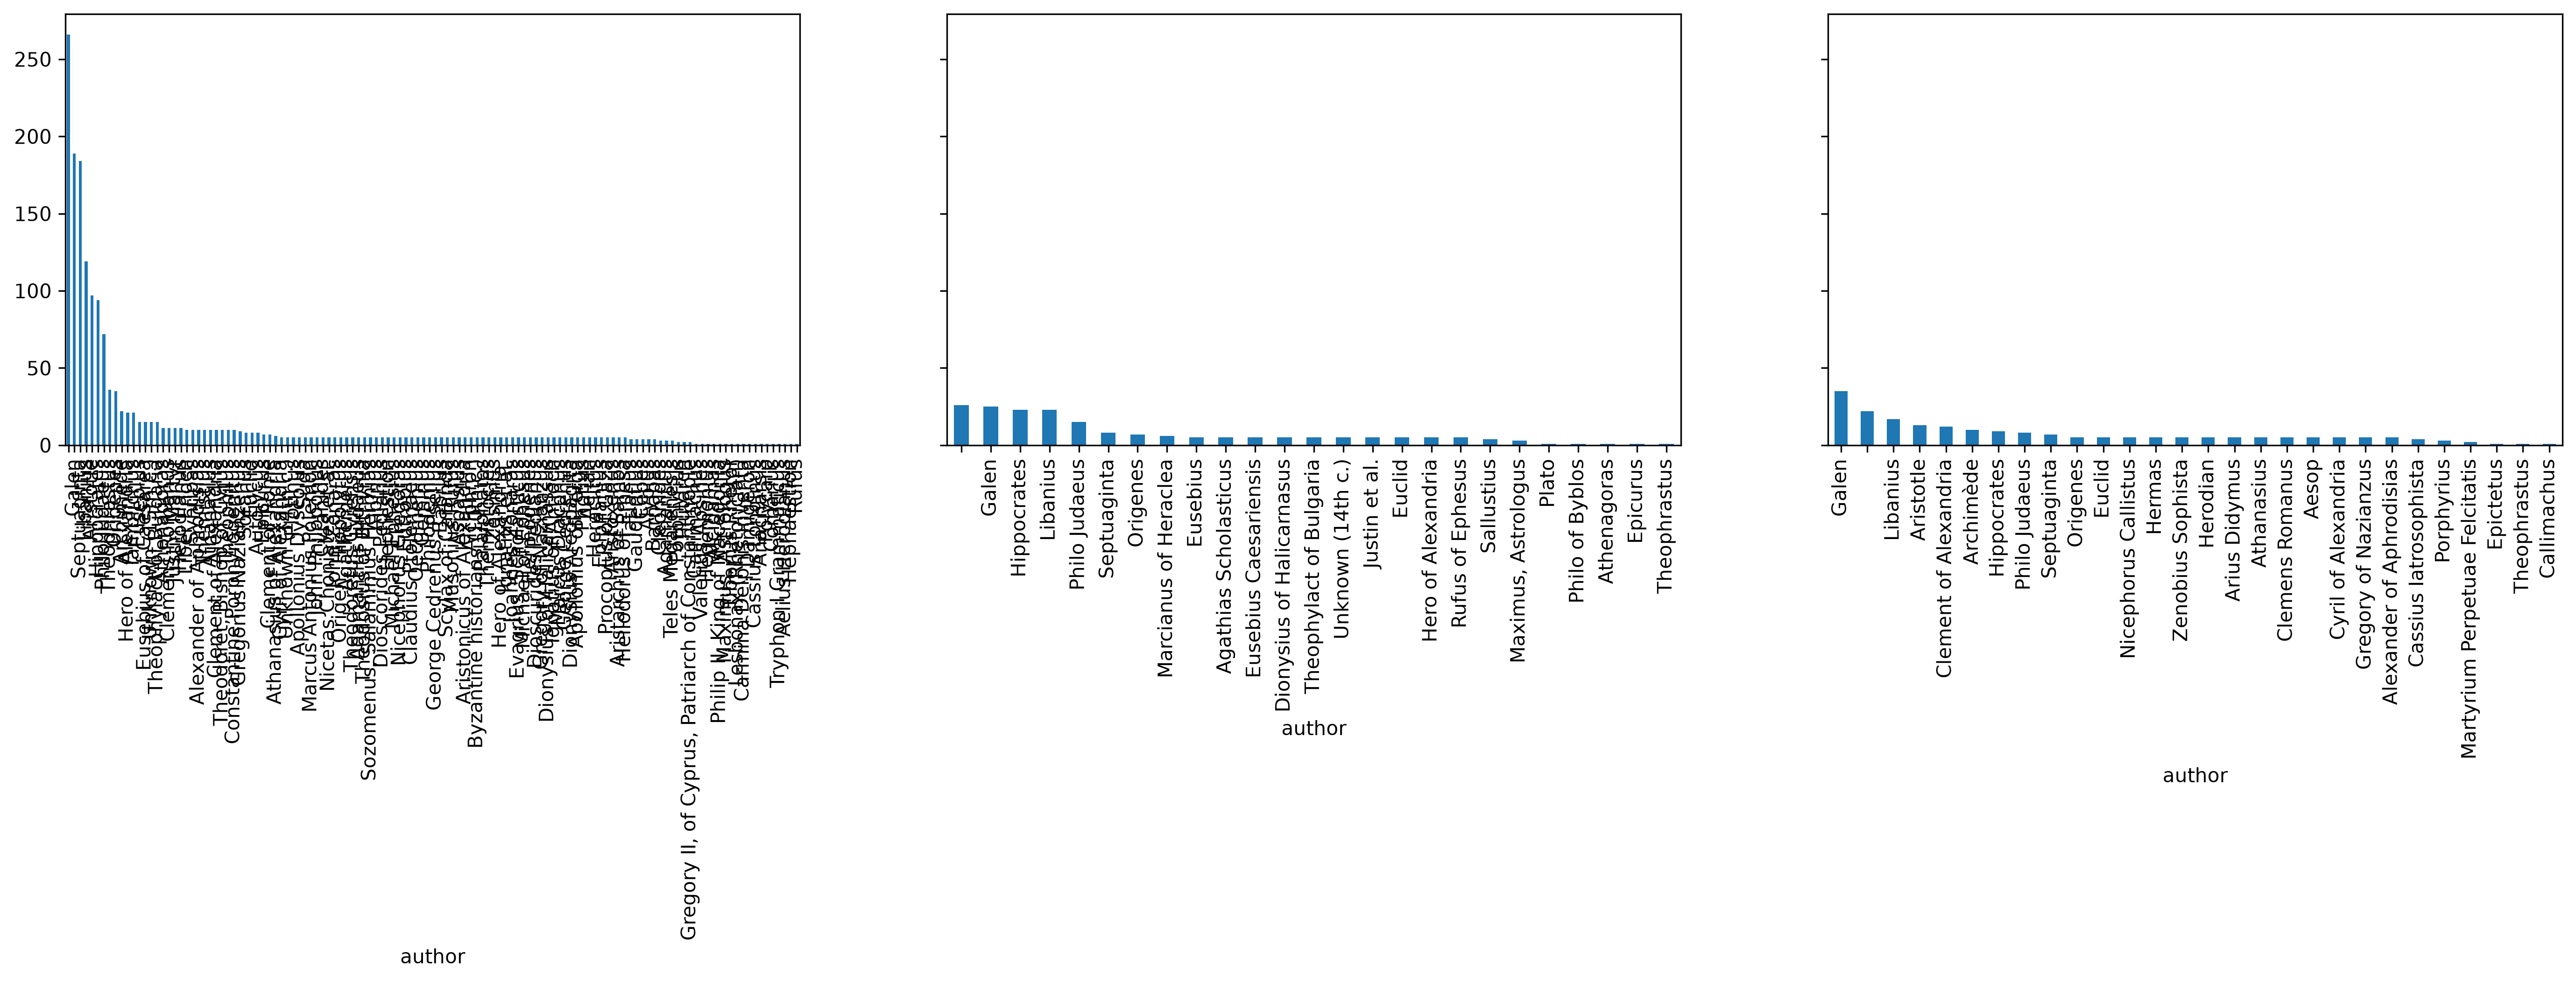

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, dpi=300, figsize = (23, 4), sharey=True)
train.author.value_counts().plot.bar(ax=ax1)
dev.author.value_counts().plot.bar(ax=ax2)
test.author.value_counts().plot.bar(ax=ax3)
fig.savefig(make_file_name("samples.png"))

## Util functions

In [6]:
def assign_normalization(dfw):
    dfw.normalized._dataframe = dfw.dataframe.fillna(0)
    
def get_scores(scores, distance: float, col=METRICKEY, noprint=False) -> None:

    if "distance" in col.lower():
        scores["Attribution"] = scores[col] <= distance
    else:
        scores["Attribution"] = scores[col] >= distance
    
    pos = scores[scores.IsAPair].Attribution.value_counts().to_dict()
    negs = scores[~scores.IsAPair].Attribution.value_counts().to_dict()
    
    tp = pos.get(True, 0)
    fn = pos.get(False, 0)
    fp = negs.get(True, 0)
    tn = negs.get(False, 0)
    
    if noprint is False:
        print(f"True positives: {tp}\nFalse Negative {fn}")
        print(f"True Negative {tn}")
        print(f"False positives: {fp}\nAccuracy: {tp/(fn+tp):.2f}")
    return tp, fp, tn, fn

## Automatically retrieve some constant parameters

In [7]:
POS_COLS = [
    col
    for col in train.columns
    if col.startswith("$POS$")
]
FW_COLS = [
    col
    for col in train.columns
    if col.startswith("$MFW$")
]
TRIG_COLS = [
    col
    for col in train.columns
    if col.startswith("$TRI$")
]
KEEP = [] + (
    POS_COLS if USE_POS else []
) + (
    FW_COLS if USE_FW else []
) + (
    TRIG_COLS if USE_TRIG else []
)
IGNORE = [
    col for col in train.columns
    if col not in KEEP
]

print(IGNORE_KEYS)

['file', 'author', 'textgroup', 'title', 'tokens', 'length', 'modified_text']


## Get DataFrameWrapper

In [8]:
data = DataframeWrapper(train, target="author", label=["author", "title"], x_ignore=IGNORE)
assign_normalization(data)
data_dev = DataframeWrapper(dev, target="author", label=["author", "title"], x_ignore=IGNORE)
data_dev.update_features(data.features)
assign_normalization(data_dev)
data_test = DataframeWrapper(test, target="author", label=["author", "title"], x_ignore=IGNORE)
data_test.update_features(data.features)
assign_normalization(data_test)
data._x_ignore

('file', 'author', 'title', 'textgroup', 'tokens', 'length', 'modified_text')

## CHecking some details

In [9]:
data.normalized.xs.head()

,$POS$r-l-a,$POS$a-l-n,$POS$l-n-v,$POS$n-r-l,$POS$l-a-n,$POS$n-d-v,$POS$a-n-v,$POS$n-v-d,$POS$n-b-n,$POS$v-r-l,...,$MFW$μάλα,$MFW$πλησίον,"$MFW$εἴρηται,",$MFW$μηδ´,$MFW$ἐκείνους,"$MFW$καὶ,","$MFW$τοῦ,",$MFW$αὐτῷ.,$MFW$ῥωμαίοις,"$MFW$τουτέστι,"
90,0.028351,0.012887,0.051546,0.025773,0.023196,0.012887,0.007732,0.025773,0.007732,0.028351,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
558,0.016129,0.028226,0.024194,0.024194,0.012097,0.016129,0.000000,0.004032,0.060484,0.064516,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
291,0.014451,0.028902,0.020231,0.014451,0.037572,0.026012,0.005780,0.005780,0.017341,0.026012,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
134,0.011211,0.022422,0.042601,0.011211,0.026906,0.031390,0.002242,0.013453,0.040359,0.017937,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1903,0.009456,0.014184,0.063830,0.016548,0.040189,0.023641,0.016548,0.021277,0.035461,0.009456,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Training

In [10]:
models, train_trainer = train_dataframewrappers(
    train=data,
    dev=data_dev,
    test=data_test,
    optim="Adam",
    accelerator="mps",
    # 2e-5, Batch 32
    learning_rate=LR,
    margin=1,
    dimension=SIZE,
    loss=LOSS,
    pos_strategy="easy",
    neg_strategy="semihard",
    sample=SAMPLE,
    batch_size=BATCH,
    gpus=1,
    dropout=DROPOUT,
    min_epochs=100,
    miner_for_dev=DEV_MINER,
    split_dim=find_index_of_first_change(data.features) if SPLIT else None,
    patience=20
    #loss="triplet"
)


You have turned on `Trainer(detect_anomaly=True)`. This will significantly slow down compute speed and is recommended only for model debugging.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

Testing: |          | 0/? [00:00<?, ?it/s]

Testing DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  9.99it/s]

Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  9.60it/s]


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_auroc            0.867944061756134
        test_loss            1.159487009048462
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [11]:
models.eval()

SiameseFeatureModule(
  (aucroc): BinaryAUROC()
  (distance): SNRDistance()
  (loss_func): SignalToNoiseRatioContrastiveLoss(
    (distance): SNRDistance()
    (reducer): MultipleReducers(
      (reducers): ModuleDict(
        (pos_loss): AvgNonZeroReducer()
        (neg_loss): AvgNonZeroReducer()
      )
      (default_reducer): MeanReducer()
    )
  )
  (miner): BatchEasyHardMiner(
    (distance): SNRDistance()
  )
  (encoder): Sequential(
    (0): BatchNorm1d(1100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): Linear(in_features=1100, out_features=64, bias=True)
  )
)

In [12]:
#pd.DataFrame({key:val for key, val in train_trainer.logger.history.items() if len(val) > 1})

### Get first FP distance

In [13]:
trainer = pl.Trainer(
    accelerator="mps",
    devices=1
)
scores = get_df_prediction(trainer, model=models, compared=data)
#scores
print(f"ROC: {roc_auc_score(scores.IsAPair, scores.Probability)}")

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Predicting DataLoader 0:  99%|█████████▉| 217/219 [00:01<00:00, 187.09it/s]

Predicting DataLoader 0: 100%|█████████▉| 218/219 [00:01<00:00, 187.11it/s]

Predicting DataLoader 0: 100%|██████████| 219/219 [00:01<00:00, 175.83it/s]

Predicting DataLoader 0: 100%|██████████| 219/219 [00:01<00:00, 175.60it/s]

ROC: 0.8422929429419528


In [14]:
scores[~scores.IsAPair].sort_values("Distance").head()

,ComparedClass,ComparedLabel,ComparatorClass,ComparatorLabel,Distance,Probability,Attribution,IsAPair,K
2253684,\n,\n - De ecclesiastica theologia,Eusebius of Caesarea,Eusebius of Caesarea - De Ecclesiastica Theolo...,0.082297,0.917703,True,False,0
721559,Eusebius of Caesarea,Eusebius of Caesarea - De Ecclesiastica Theolo...,\n,\n - De ecclesiastica theologia,0.085825,0.914175,True,False,0
1209370,Hippocrates,Hippocrates - De articulis,Galen,Galen - De crisibus,0.285242,0.714758,True,False,0
294995,Hippocrates,Hippocrates - Prognosticon,Galen,Galen - De crisibus,0.323755,0.676245,True,False,0
961595,Hippocrates,Hippocrates - De diaeta in morbis acutis,Galen,Galen - De crisibus,0.326269,0.673731,True,False,0


## Evaluating Dev for Test Threshold

In [15]:
trainer = pl.Trainer(
    accelerator="mps",
    devices=1
)
dev_pairs = get_df_prediction(trainer, model=models, compared=data_dev)
#scores
print(f"ROC: {roc_auc_score(dev_pairs.IsAPair, dev_pairs.Probability)}")

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Predicting DataLoader 0:  92%|█████████▏| 23/25 [00:00<00:00, 182.95it/s]

Predicting DataLoader 0:  96%|█████████▌| 24/25 [00:00<00:00, 181.83it/s]

Predicting DataLoader 0: 100%|██████████| 25/25 [00:00<00:00, 103.68it/s]

Predicting DataLoader 0: 100%|██████████| 25/25 [00:00<00:00, 103.08it/s]

ROC: 0.8780617556896441


In [16]:
dev_pairs[~dev_pairs.IsAPair].sort_values("Distance").head()

,ComparedClass,ComparedLabel,ComparatorClass,ComparatorLabel,Distance,Probability,Attribution,IsAPair,K
35166,Hero of Alexandria,Hero of Alexandria - Metrica,Euclid,Euclid - Optica,0.389876,0.610124,True,False,0
25202,Hero of Alexandria,Hero of Alexandria - Metrica,Euclid,Euclid - Optica,0.456169,0.543831,True,False,0
12286,Hero of Alexandria,Hero of Alexandria - Metrica,Euclid,Euclid - Optica,0.465105,0.534895,True,False,0
35153,Hero of Alexandria,Hero of Alexandria - Metrica,Euclid,Euclid - Optica,0.472007,0.527993,True,False,0
29538,Hero of Alexandria,Hero of Alexandria - Metrica,Euclid,Euclid - Optica,0.475267,0.524733,True,False,0


<Axes: >

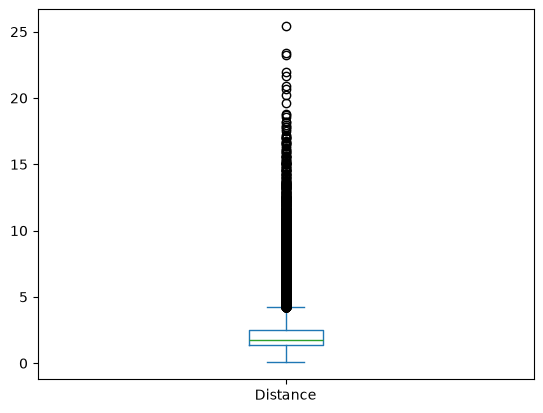

In [17]:
dev_pairs.Distance.plot.box()

In [18]:
#clip = scores.Distance.apply(lambda x: 2 if x > 2 else x)
#scores.Distance = clip

## Study AUCROC

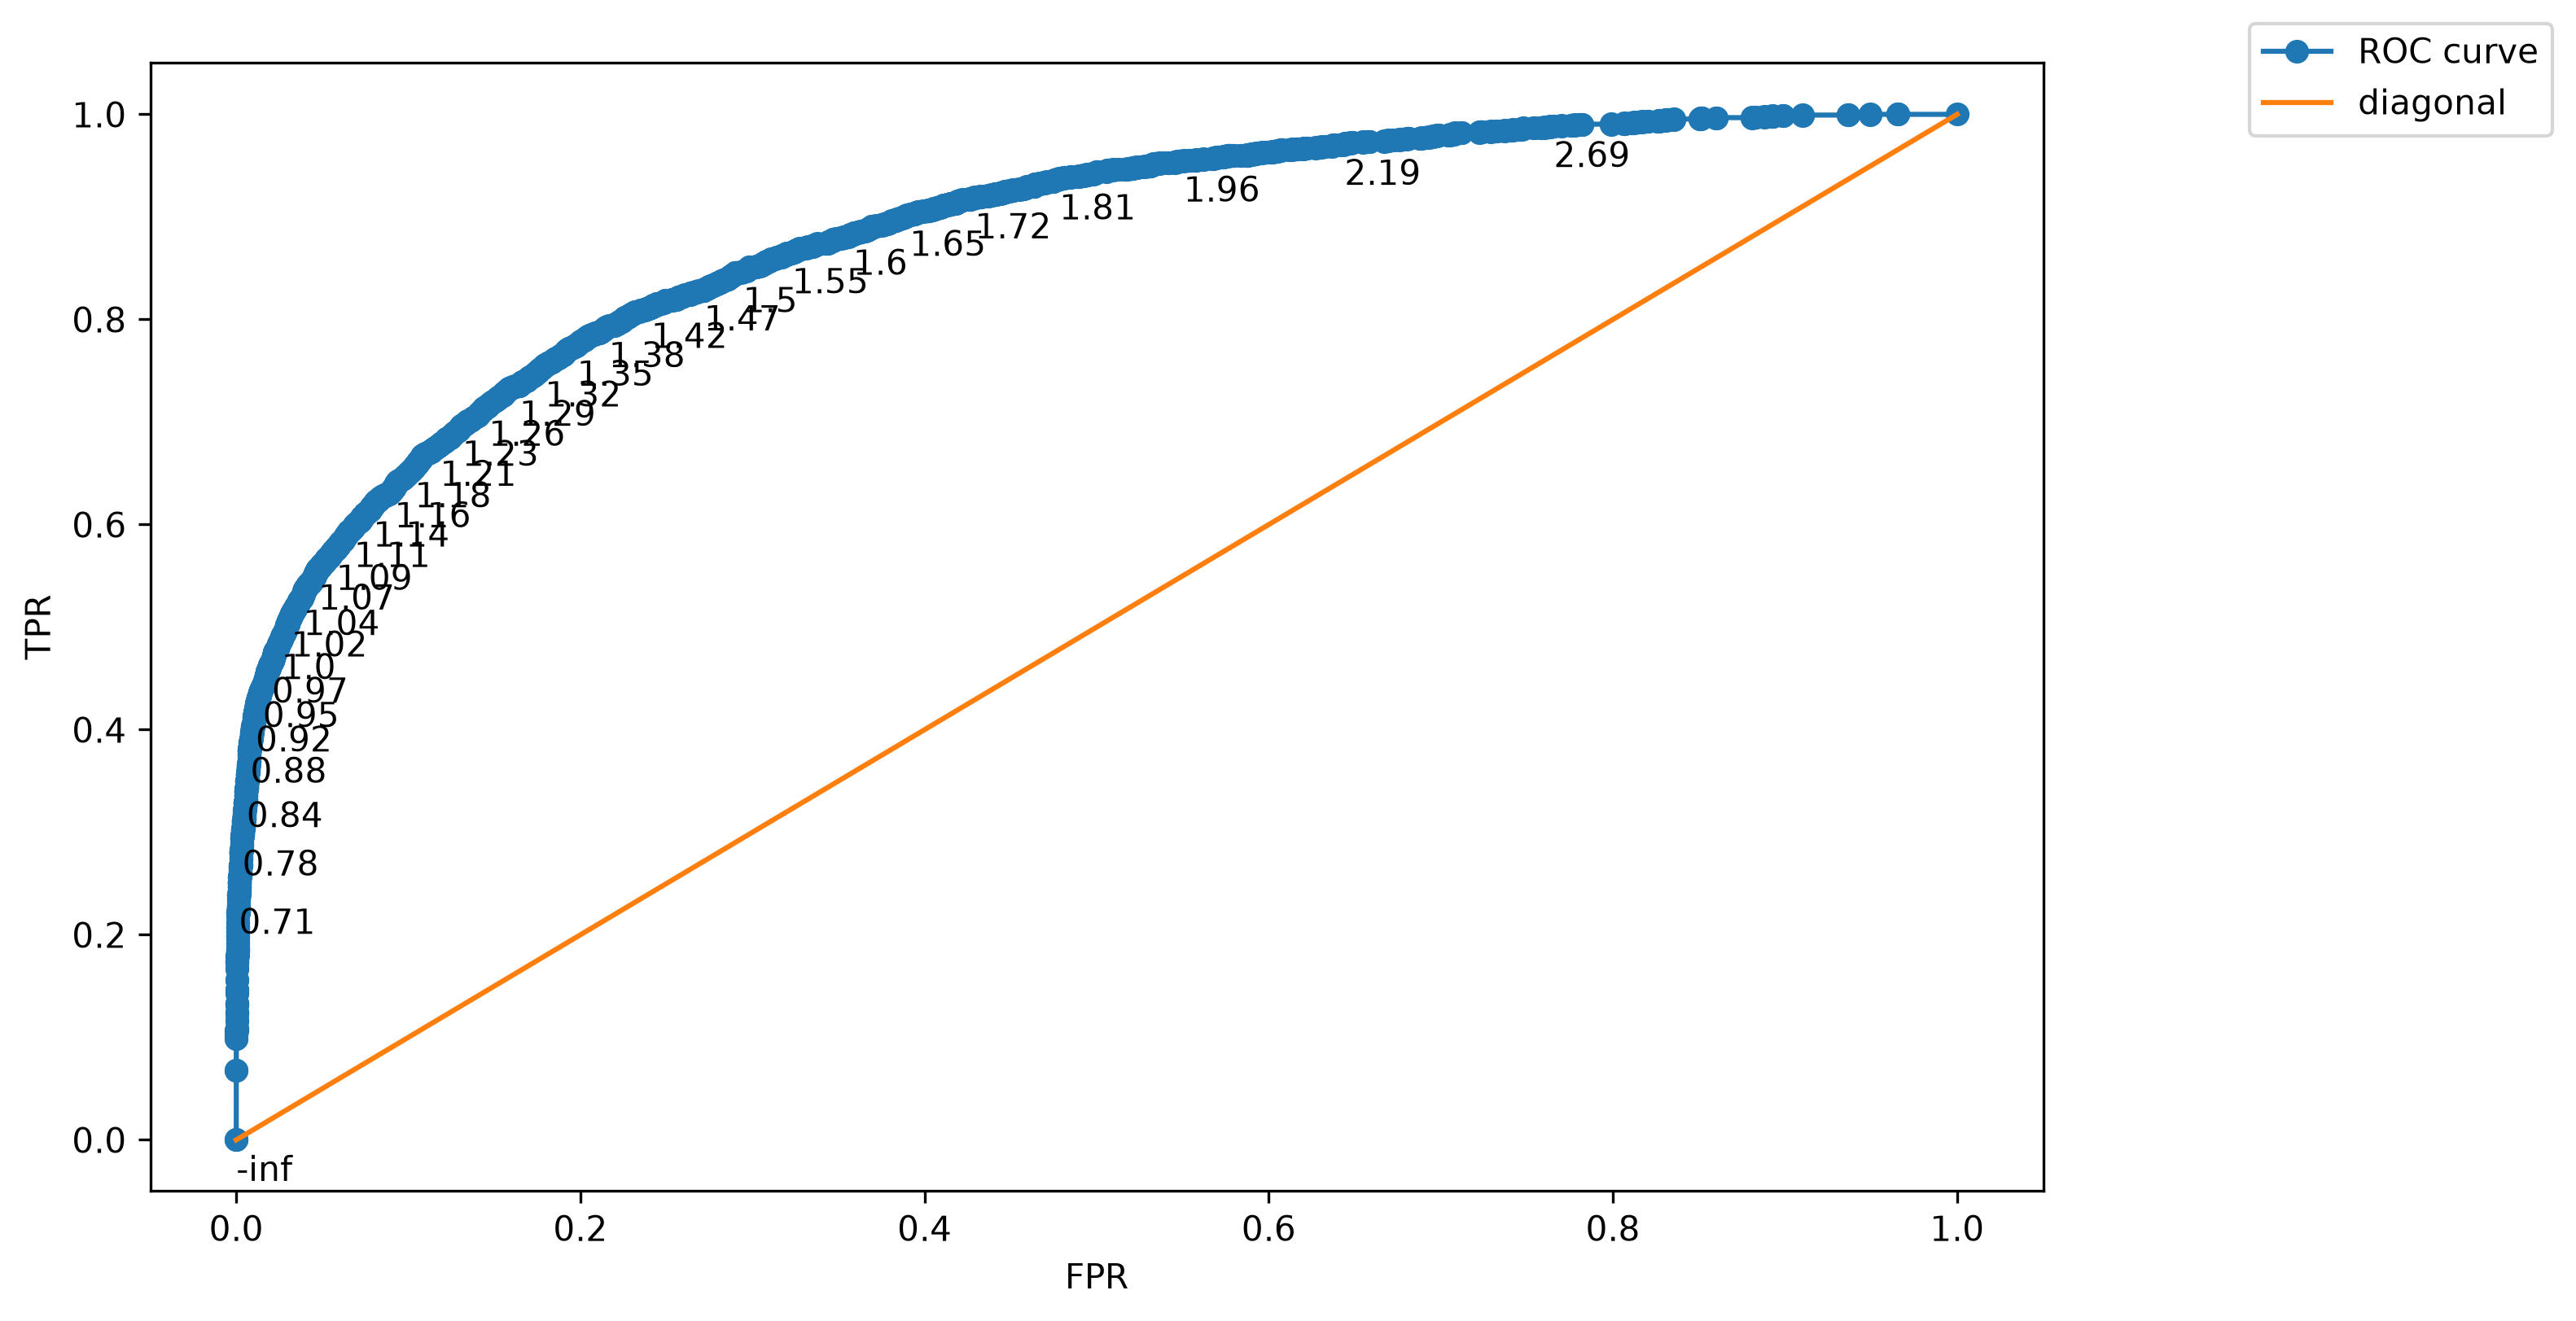

In [19]:
plot_aucroc_curve(dev_pairs.IsAPair, dev_pairs[METRICKEY], nth=100, is_dist=ISDIST)
ax = plt.gca()
ax.legend(bbox_to_anchor=(1.1, 1.05))
plt.gcf().savefig(make_file_name("aucroc-dev.png"))

/var/folders/0q/5tjc2wr91qv1h69jgm1s1mzc0000gp/T/ipykernel_98921/2486278686.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


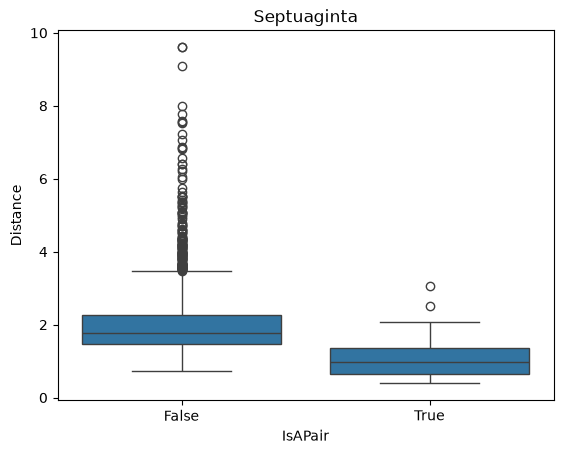

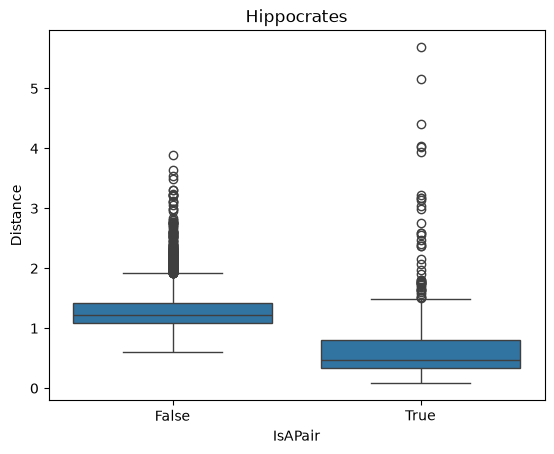

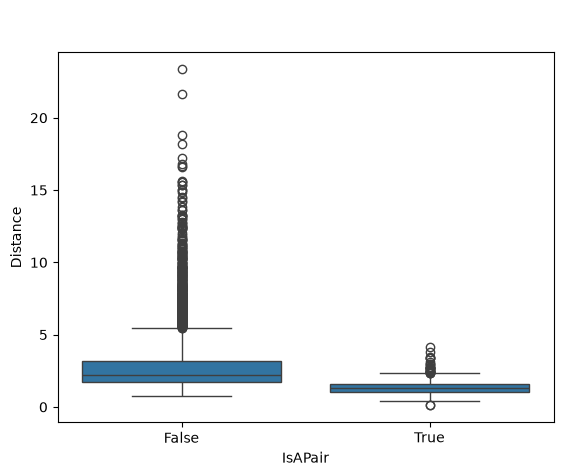

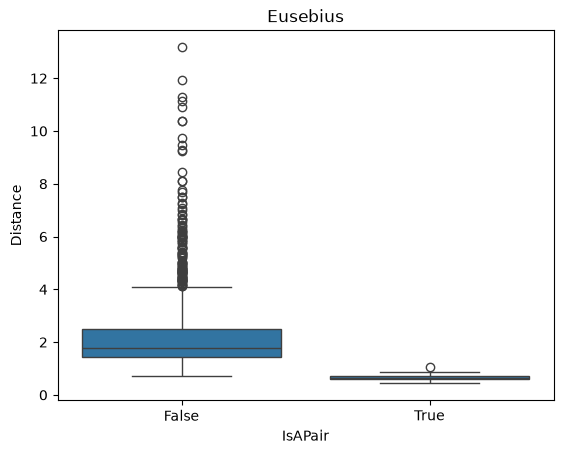

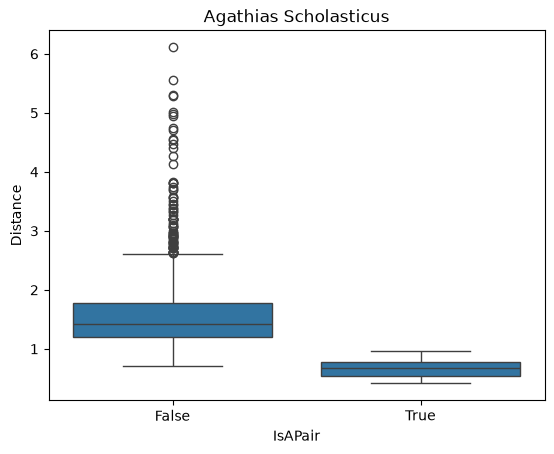

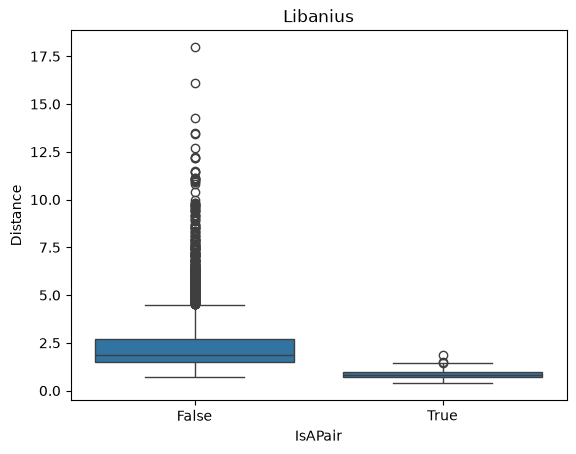

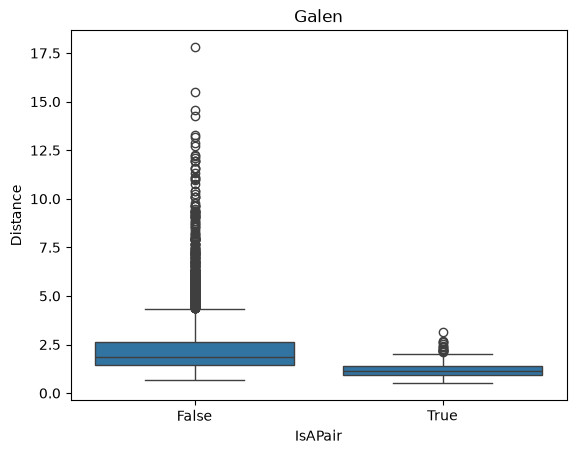

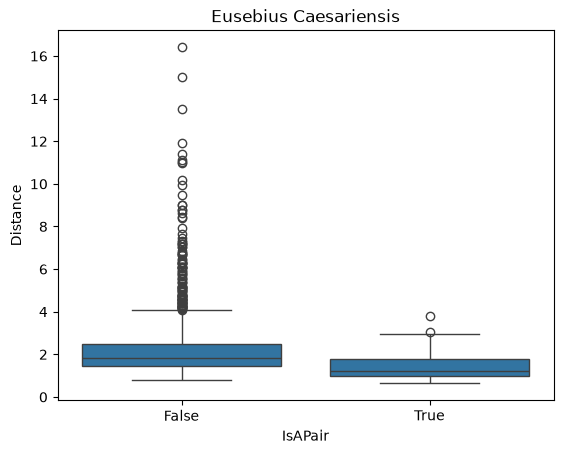

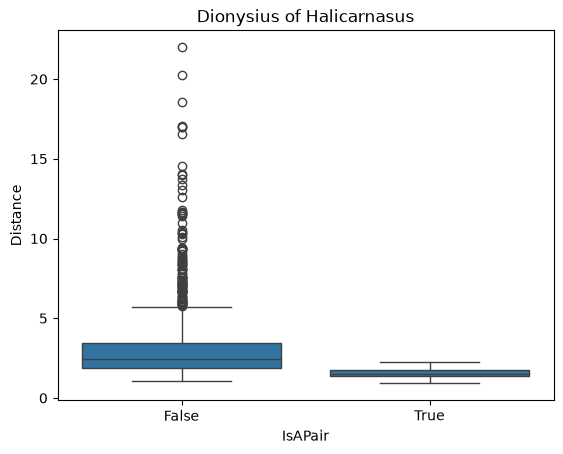

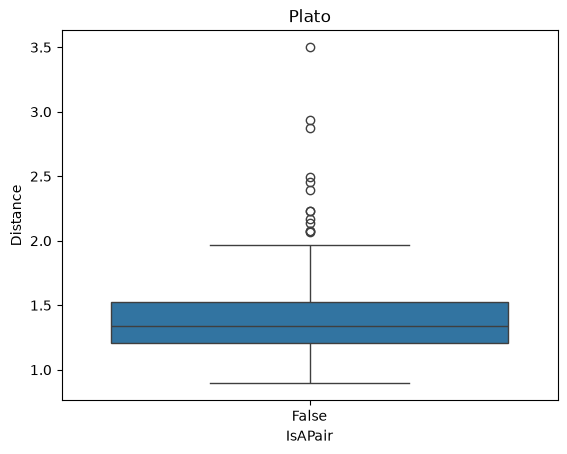

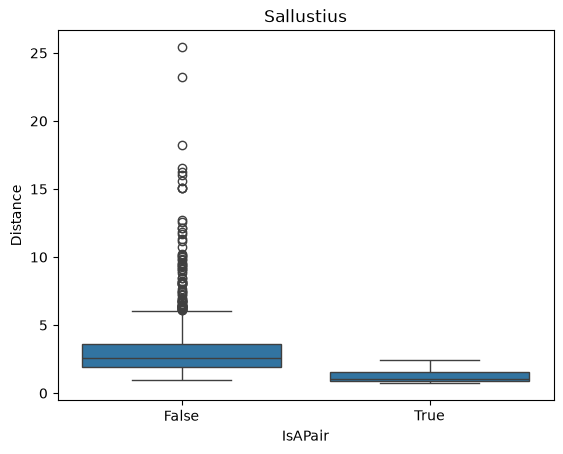

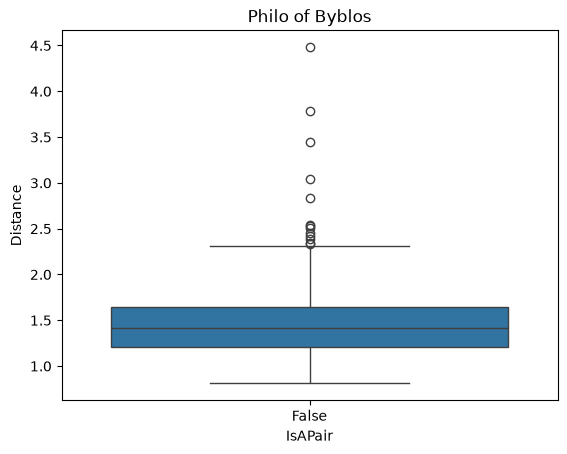

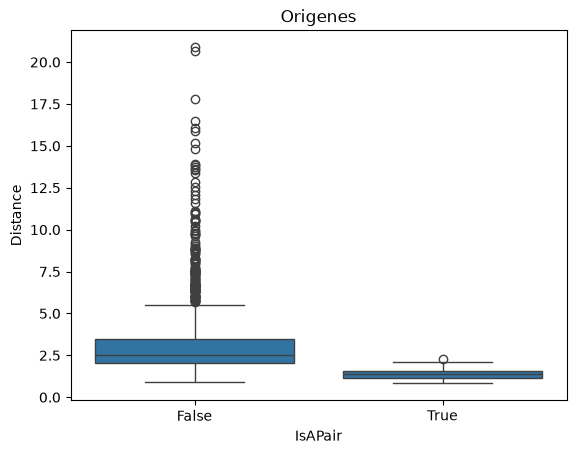

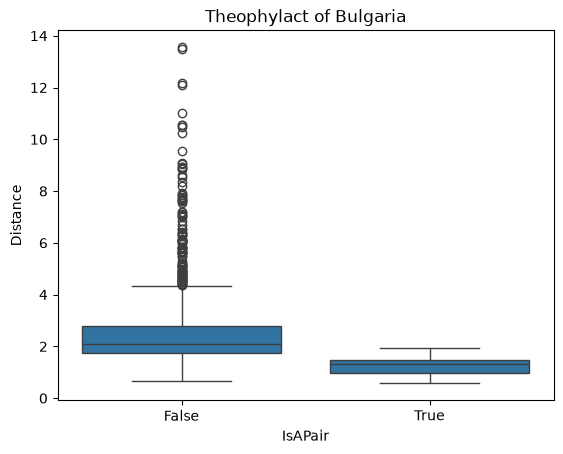

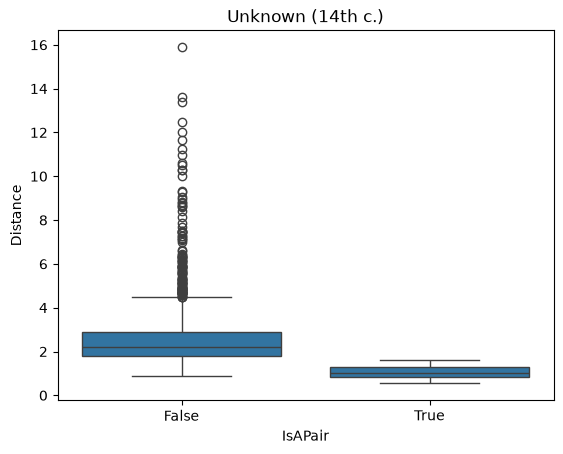

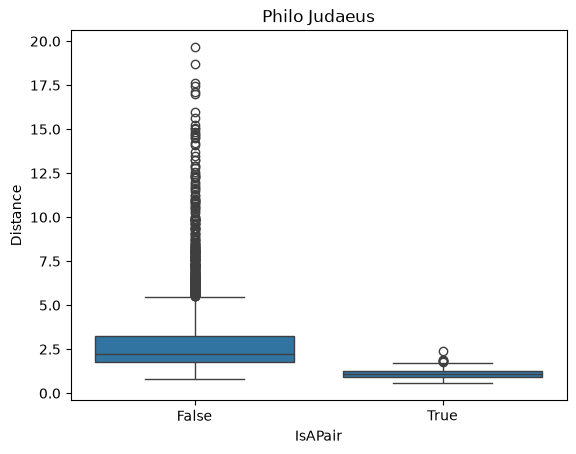

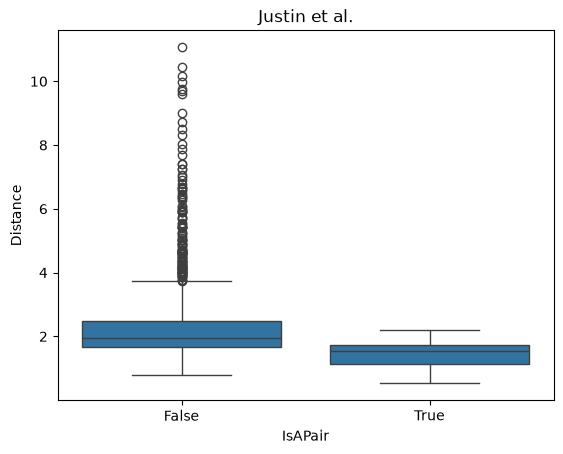

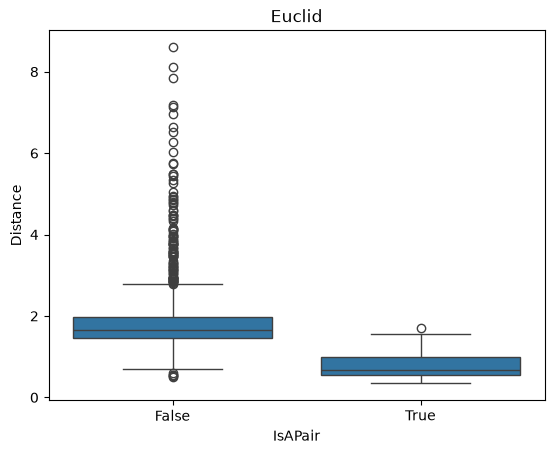

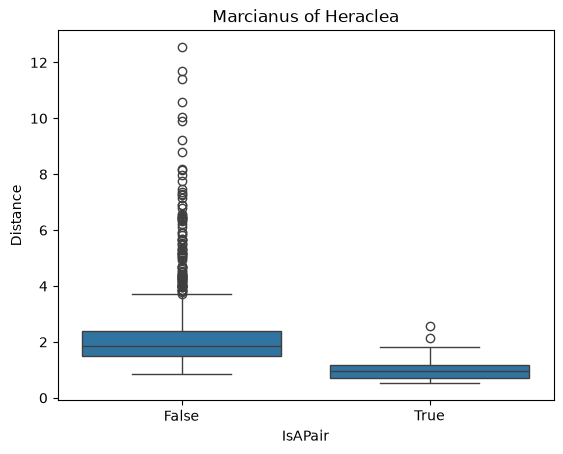

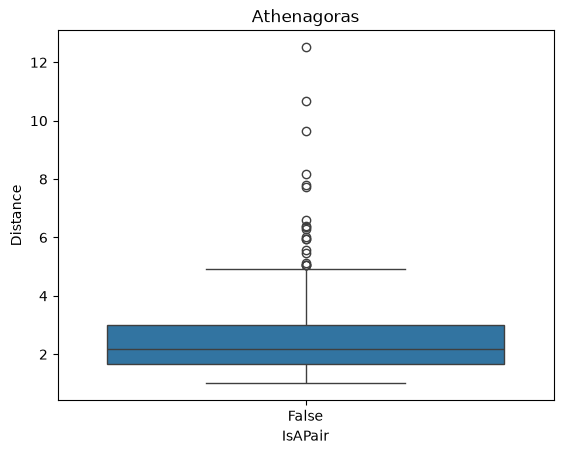

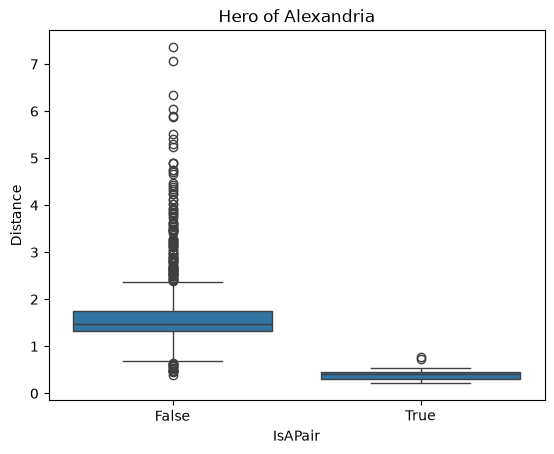

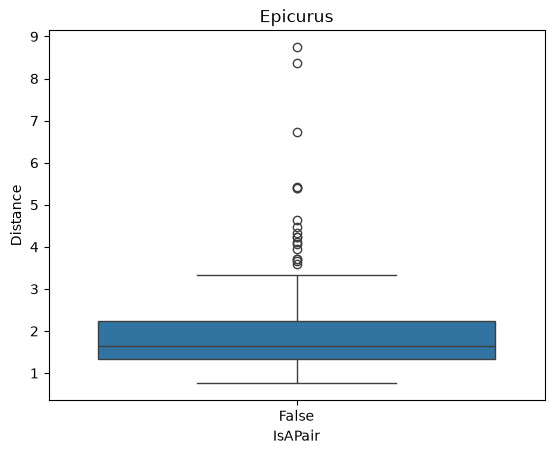

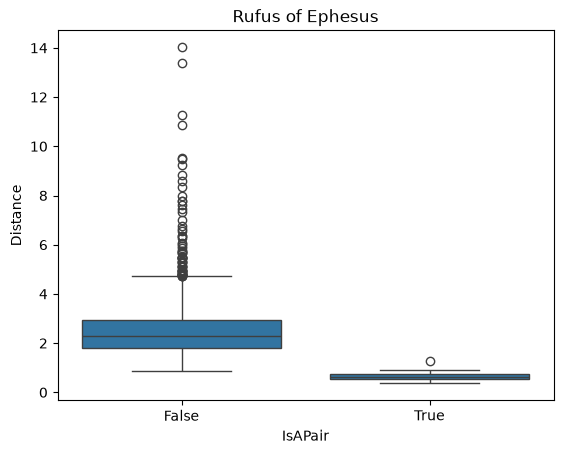

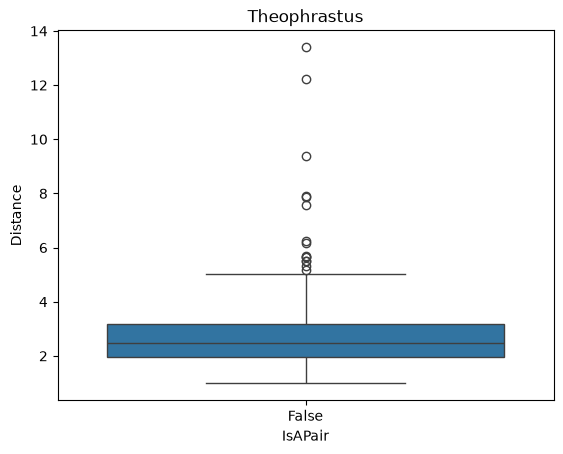

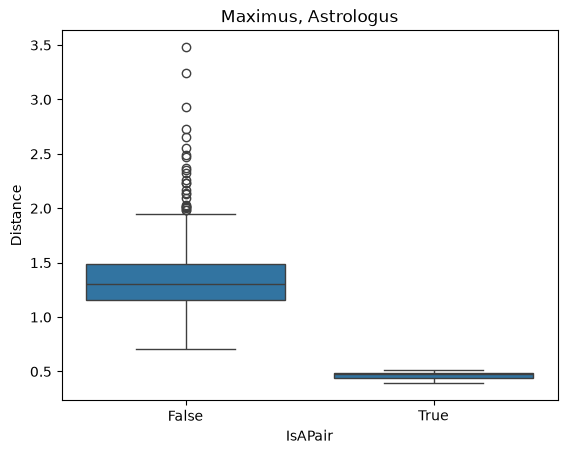

In [20]:
for cls in dev_pairs.ComparedClass.unique():
    plt.figure()
    sns.boxplot(data=dev_pairs[(dev_pairs.ComparedClass==cls)], x="IsAPair", y=METRICKEY)
    plt.gca().set_title(cls)
    plt.gcf().savefig(make_file_name(f"Dev-{cls}.png"))
    #scores.groupby("ComparedClass").plot.box(y="Distance", x="IsAPair")

### Find sweet spot

In [21]:
MAX_DISTANCE = 6
get_scores(dev_pairs, MAX_DISTANCE)
print("\n===\nWithout sampling\n===\n")
get_scores(dev_pairs[(dev_pairs.ComparedLabel != dev_pairs.ComparatorLabel)], MAX_DISTANCE)

True positives: 2818
False Negative 0
True Negative 1561
False positives: 33451
Accuracy: 1.00

===
Without sampling
===

True positives: 2188
False Negative 0
True Negative 1561
False positives: 33451
Accuracy: 1.00


(2188, 33451, 1561, 0)

## Evaluating Test with Dev Threshold

In [22]:
models.eval()
MAX_DISTANCE = 6

test_pairs = get_df_prediction(trainer, model=models, compared=data_test, threshold=MAX_DISTANCE)

/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0:   0%|          | 0/27 [00:00<?, ?it/s]

Predicting DataLoader 0:   4%|▎         | 1/27 [00:00<00:00, 1424.70it/s]

...

Predicting DataLoader 0:  89%|████████▉ | 24/27 [00:00<00:00, 190.30it/s]

Predicting DataLoader 0:  93%|█████████▎| 25/27 [00:00<00:00, 190.45it/s]

Predicting DataLoader 0:  96%|█████████▋| 26/27 [00:00<00:00, 190.56it/s]

Predicting DataLoader 0: 100%|██████████| 27/27 [00:00<00:00, 188.47it/s]

Predicting DataLoader 0: 100%|██████████| 27/27 [00:00<00:00, 187.07it/s]

In [23]:
test_pairs[~test_pairs.IsAPair].sort_values(METRICKEY).head()

,ComparedClass,ComparedLabel,ComparatorClass,ComparatorLabel,Distance,Probability,Attribution,IsAPair,K
16003,Aristotle,Aristotle - De spiritu,Theophrastus,Theophrastus - Περί Ἰδρώτων,0.513911,0.486089,True,False,0
22032,\n,\n - Exhortatio ad martyrium,Origenes,Origenes - Exhortatio ad martyrium,0.545324,0.454676,True,False,0
20349,Aristotle,Aristotle - De animalium incessu,Theophrastus,Theophrastus - Περί Ἰδρώτων,0.596419,0.403581,True,False,0
8845,Hippocrates,Hippocrates - De locis in homine,Herodian,Herodian - Ab excessu divi Marci,0.602166,0.397834,True,False,0
17637,\n,\n - Exhortatio ad martyrium,Origenes,Origenes - Exhortatio ad martyrium,0.617857,0.382143,True,False,0


In [24]:
print(f"ROC: {roc_auc_score(test_pairs.IsAPair, test_pairs.Probability)}")
MAX_DISTANCE = 6
get_scores(test_pairs, MAX_DISTANCE)
print("\n===\nWithout sampling\n===\n")
get_scores(test_pairs[(test_pairs.ComparedLabel != test_pairs.ComparatorLabel)], MAX_DISTANCE)

ROC: 0.8659383587445884
True positives: 2751
False Negative 1
True Negative 1401
False positives: 39737
Accuracy: 1.00

===
Without sampling
===

True positives: 2037
False Negative 1
True Negative 1401
False positives: 39737
Accuracy: 1.00


(2037, 39737, 1401, 1)

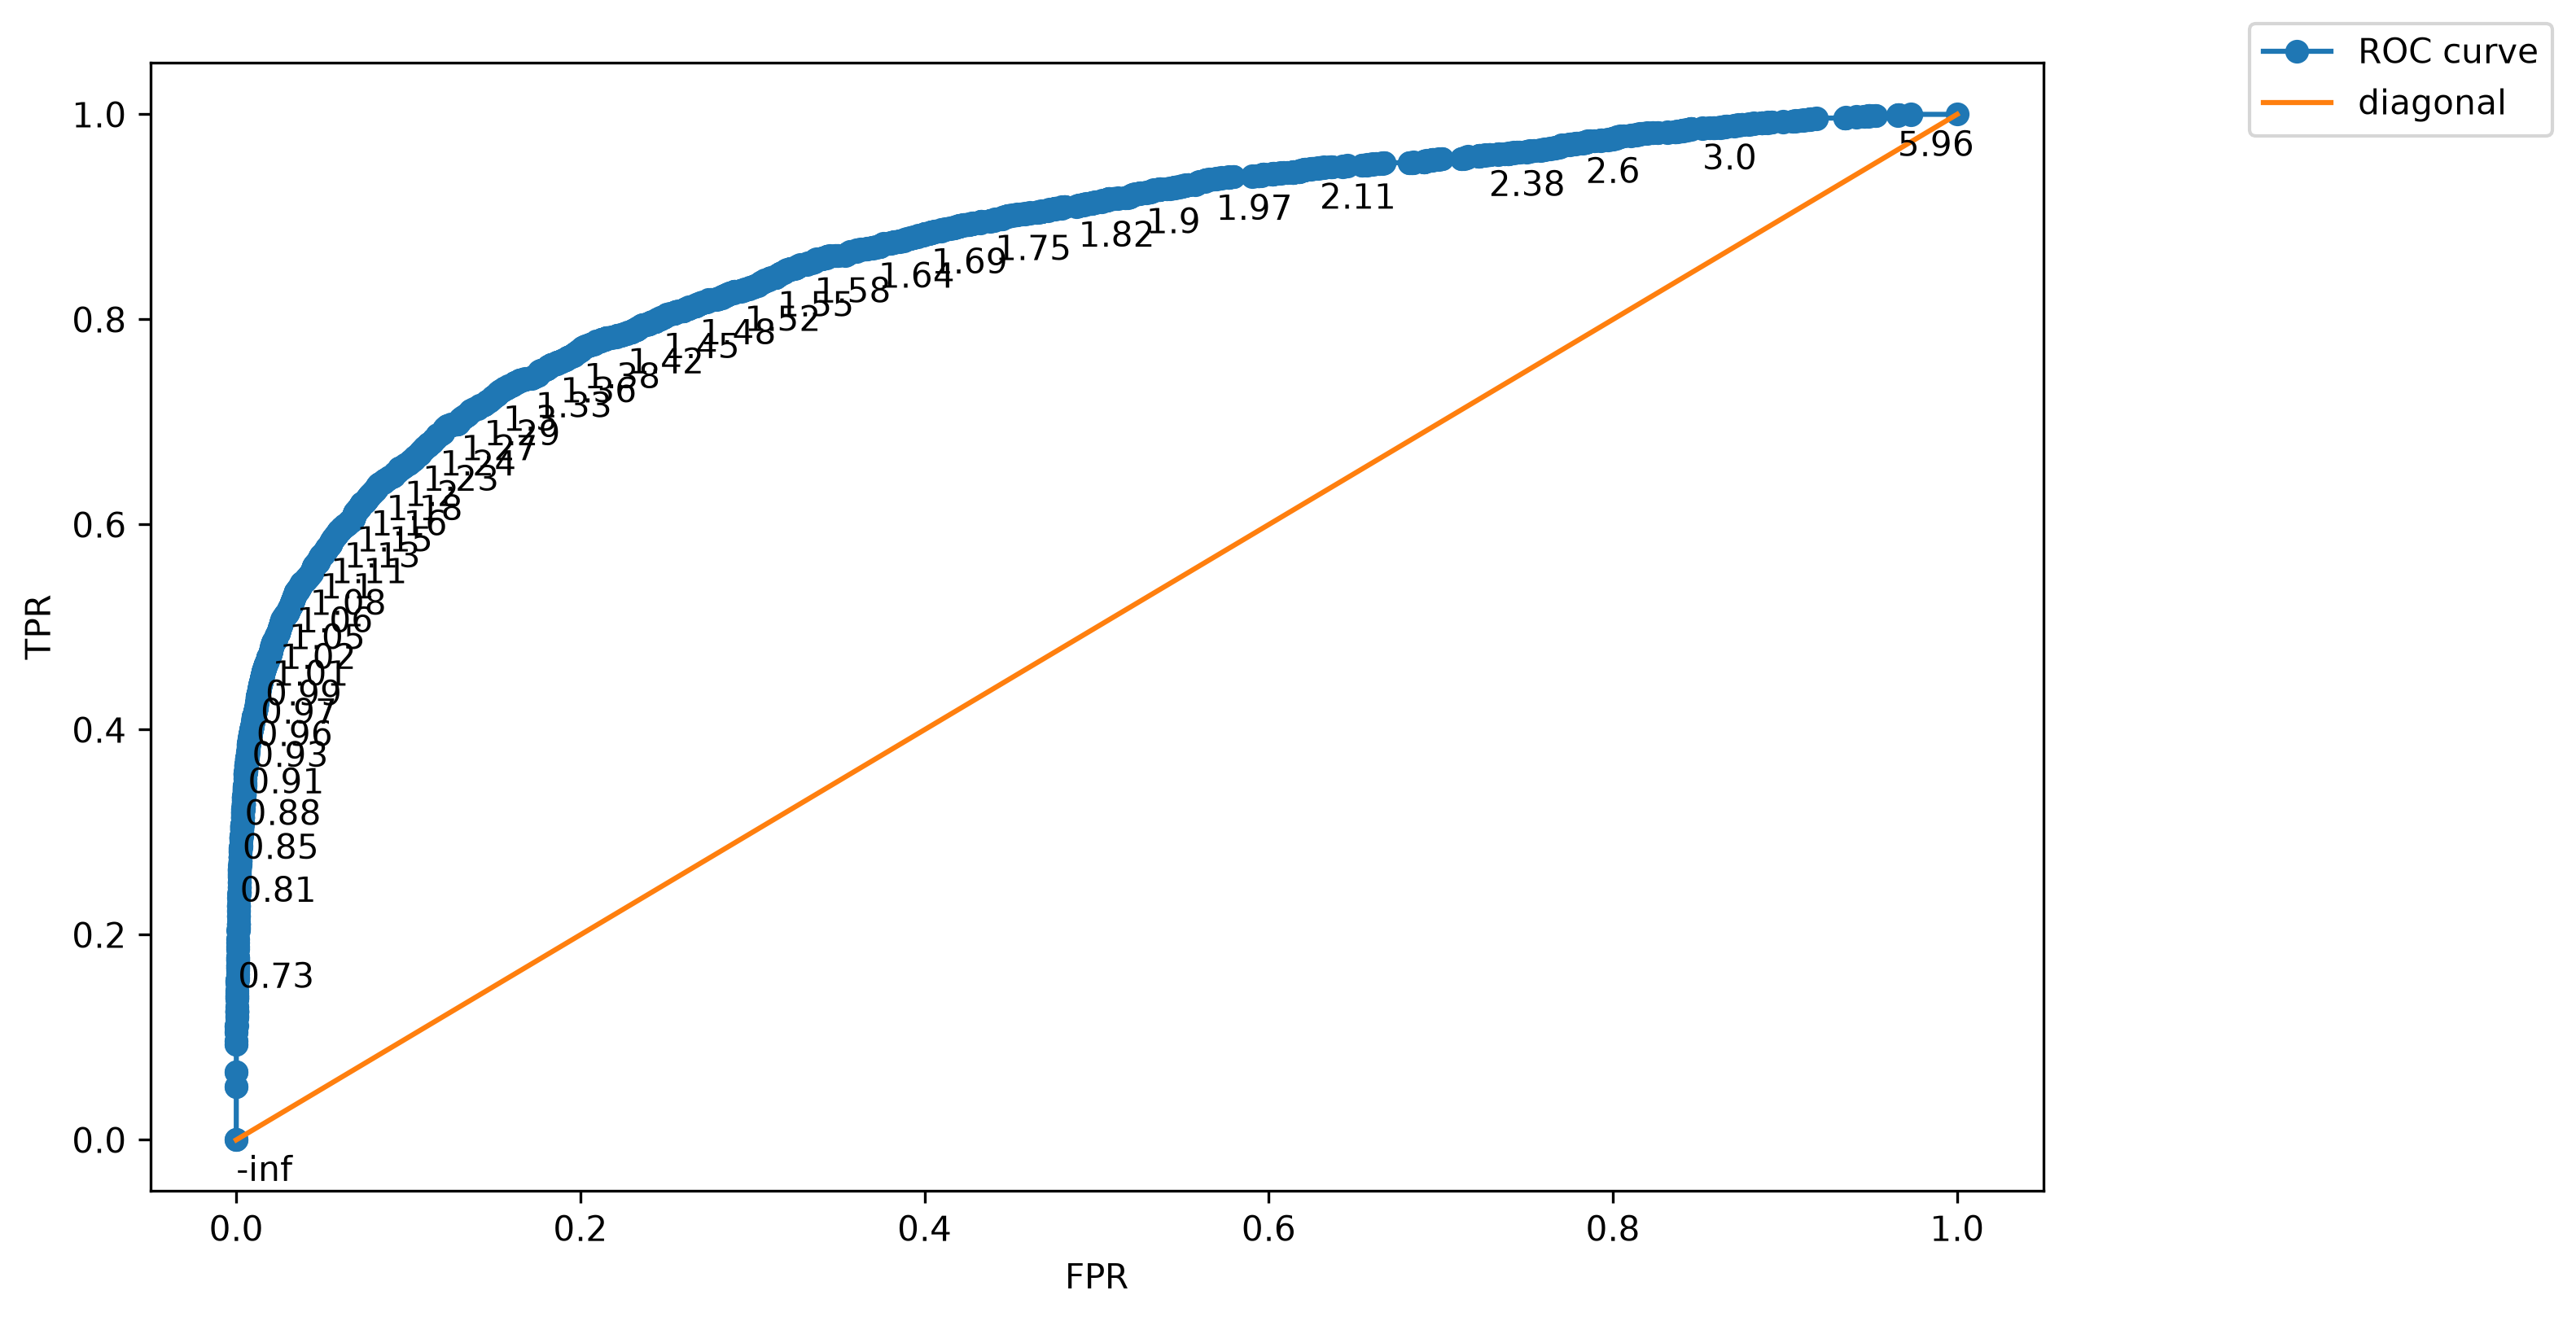

In [25]:
plot_aucroc_curve(test_pairs.IsAPair, test_pairs[METRICKEY], nth=75, is_dist=ISDIST)
ax = plt.gca()
ax.legend(bbox_to_anchor=(1.1, 1.05))
plt.gcf().savefig(make_file_name("test-aucroc.png"))

In [26]:
dev_pairs.to_csv(make_file_name("test-results.csv"))

## On Voicu !

In [27]:
import regex as re
import json
import unicodedata

df = pd.read_csv("pc-features.csv")
DFW = DataframeWrapper(df, label=("author", "title"), target="title", 
                       x_ignore=[col for col in df.columns if col not in data.features])
#
print(len(DFW.features))
print(len(data.features))
DFW.update_features(data.features)
assign_normalization(DFW)
#DFW._features = data.features
print(len(data.features))
print(len(DFW.features))

847
1100
1100 new features found, setting them as 0.
1100
1100


In [28]:
models.eval()
pairs = get_df_prediction(
    trainer, model=models, 
    compared=DFW, #comparator=DFW, 
    threshold=MAX_DISTANCE
)
pairs = pairs[pairs.ComparedLabel != pairs.ComparatorLabel]

/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0:   0%|          | 0/9 [00:00<?, ?it/s]

Predicting DataLoader 0:  11%|█         | 1/9 [00:00<00:00, 1146.92it/s]

...

Predicting DataLoader 0:  67%|██████▋   | 6/9 [00:00<00:00, 148.54it/s]

Predicting DataLoader 0:  78%|███████▊  | 7/9 [00:00<00:00, 142.99it/s]

Predicting DataLoader 0:  89%|████████▉ | 8/9 [00:00<00:00, 142.21it/s]

Predicting DataLoader 0: 100%|██████████| 9/9 [00:00<00:00, 65.69it/s] 

Predicting DataLoader 0: 100%|██████████| 9/9 [00:00<00:00, 65.07it/s]

In [29]:
pairs["ComparedClass"] = pairs.ComparedLabel.apply(lambda x: x.split()[0].strip())
pairs["ComparatorClass"] = pairs.ComparatorLabel.apply(lambda x: x.split()[0].strip())
pairs["IsAPair"] = pairs.ComparedClass == pairs.ComparatorClass
pairs.head()

,ComparedClass,ComparedLabel,ComparatorClass,ComparatorLabel,Distance,Probability,Attribution,IsAPair,K
0,PC20b,PC20b - QuodMariSimilisSitHaecVita,PC20,PC20 - InIlludCredidiPropterQuodLocutusSum,1.871819,-0.871819,True,False,0
1,PC20b,PC20b - QuodMariSimilisSitHaecVita,PC2,PC2 - DeJoseph,1.151269,-0.151269,True,False,0
2,PC20b,PC20b - QuodMariSimilisSitHaecVita,PC9,PC9 - InCenturionem,1.568014,-0.568014,True,False,0
3,PC20b,PC20b - QuodMariSimilisSitHaecVita,PC20,PC20 - InZacchaeumPublicanum,2.027213,-1.027213,True,False,0
4,PC20b,PC20b - QuodMariSimilisSitHaecVita,PC20,PC20 - DeTurtureSeuDeEcclesiaSermo,1.164993,-0.164993,True,False,0


In [30]:
pairs[f"Rounded{METRICKEY}"] = pairs[METRICKEY].round(3)
dists = sorted(pairs[f"Rounded{METRICKEY}"].unique())

pairs["TestTPR"] = .0
pairs["TestPre"] = .0
pairs["TestFPR"] = 1.0
pairs["TestFP"] = -1
pairs["TestFN"] = -1
pairs["TestTP"] = -1
pairs["TestTN"] = -1
pairs["DevTPR"] = .0
pairs["DevPre"] = .0
pairs["DevFPR"] = 1.0
pairs["DevFP"] = -1
pairs["DevFN"] = -1
pairs["DevTP"] = -1
pairs["DevTN"] = -1

for dist in dists:
    tp, fp, tn, fn = get_scores(test_pairs, dist, col=METRICKEY, noprint=True)
    #print(tp, fp, tn, fn)
    filt = pairs[f"Rounded{METRICKEY}"] == dist
    pairs.loc[filt, "TestTPR"] = tp / max([tp+fn, 1])
    pairs.loc[filt, "TestFPR"] = fp / max([fp+tn, 1])
    pairs.loc[filt, "TestPre"] = tp / max([fp+tp, 1])
    pairs.loc[filt, "TestFP"] = fp
    pairs.loc[filt, "TestTP"] = tp
    pairs.loc[filt, "TestFN"] = fn
    pairs.loc[filt, "TestTN"] = tn
    
    # DEV
    
    tp, fp, tn, fn = get_scores(dev_pairs, dist, col=METRICKEY, noprint=True)
    #print(tp, fp, tn, fn)
    filt = pairs[f"Rounded{METRICKEY}"] == dist
    pairs.loc[filt, "DevTPR"] = tp / max([tp+fn, 1])
    pairs.loc[filt, "DevFPR"] = fp / max([fp+tn, 1])
    pairs.loc[filt, "DevPre"] = tp / max([fp+tp, 1])
    pairs.loc[filt, "DevFP"] = fp
    pairs.loc[filt, "DevTP"] = tp
    pairs.loc[filt, "DevFN"] = fn
    pairs.loc[filt, "DevTN"] = tn
    

In [31]:
pairs.sort_values("DevPre").tail()

,ComparedClass,ComparedLabel,ComparatorClass,ComparatorLabel,Distance,Probability,Attribution,IsAPair,K,RoundedDistance,...,TestFN,TestTP,TestTN,DevTPR,DevPre,DevFPR,DevFP,DevFN,DevTP,DevTN
1467,PC6,PC6 - DePoenintentiaSermo3,PC7,PC7 - DeIeiunoSermo2,0.357834,0.642166,True,False,0,0.358,...,2710,42,41138,0.055713,1.0,0.0,0,2661,157,35012
4417,PC16,PC16 - InPsalmum50Homilia2,PC18,PC18 - InParabolamDeFilioProdigo,0.345087,0.654913,True,False,0,0.345,...,2717,35,41138,0.050745,1.0,0.0,0,2675,143,35012
3642,PC16,PC16 - InPsalmum50Homilia1,PC17,PC17 - DeEleemosyna,0.360311,0.639689,True,False,0,0.360,...,2710,42,41138,0.056423,1.0,0.0,0,2659,159,35012
4555,PC7,PC7 - DeIeiunoSermo7,PC7,PC7 - DeIeiunoSermo2,0.305782,0.694218,True,True,0,0.306,...,2725,27,41138,0.040454,1.0,0.0,0,2704,114,35012
4467,PC16,PC16 - InPsalmum50Homilia1,PC16,PC16 - InPsalmum50Homilia2,0.326759,0.673241,True,True,0,0.327,...,2722,30,41138,0.046842,1.0,0.0,0,2686,132,35012


In [32]:
pairs.sort_values(["DevPre", "TestPre", "Distance"]).to_csv(make_file_name("pairs-last-experiment.csv"))